In [11]:
!pip install yfinance arch

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from arch import arch_model

In [13]:
ticker = "AAPL"
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")
data.head()

/tmp/ipykernel_2239/3778324130.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
2015-01-05,23.532715,24.064278,23.346669,23.984543,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781900,24.839487,24.075364,24.192753,237458000


In [14]:
data = data[['Close']]
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)
data.head()

Price,Close,Returns
Ticker,AAPL,
Date,,
2015-01-05,23.532715,-0.028576
2015-01-06,23.534937,0.000094
2015-01-07,23.864948,0.013925
2015-01-08,24.781900,0.037703
2015-01-09,24.808474,0.001072


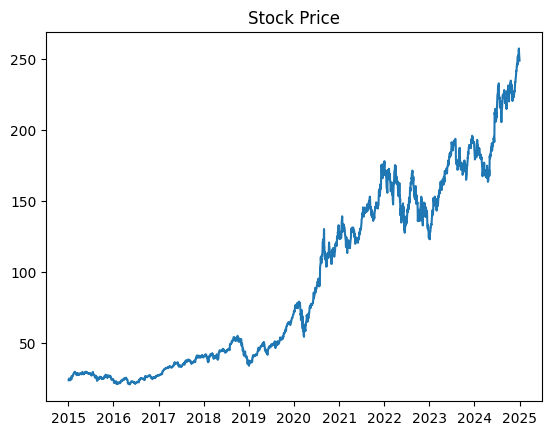

In [15]:
plt.plot(data['Close'])
plt.title("Stock Price")
plt.show()

In [16]:
result = adfuller(data['Returns'])
print("ADF:", result[0])
print("p-value:", result[1])

ADF: -15.549464407728214
p-value: 2.109106294607963e-28


In [17]:
model = arch_model(data['Returns']*100, vol='Garch', p=1, q=1)
result = model.fit()
print(result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 12484098497.828213
Iteration:      2,   Func. Count:     14,   Neg. LLF: 18205146885.383038
Iteration:      3,   Func. Count:     22,   Neg. LLF: 6250.224830407245
Iteration:      4,   Func. Count:     29,   Neg. LLF: 5025.22715028353
Iteration:      5,   Func. Count:     37,   Neg. LLF: 4792.756738795696
Iteration:      6,   Func. Count:     43,   Neg. LLF: 4789.130311078214
Iteration:      7,   Func. Count:     48,   Neg. LLF: 4789.114988770856
Iteration:      8,   Func. Count:     53,   Neg. LLF: 4789.111493281967
Iteration:      9,   Func. Count:     58,   Neg. LLF: 4789.111100846381
Iteration:     10,   Func. Count:     63,   Neg. LLF: 4789.110665128426
Iteration:     11,   Func. Count:     68,   Neg. LLF: 4789.110663943991
Iteration:     12,   Func. Count:     72,   Neg. LLF: 4789.110663943935
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4789.110663943991
            Iterations: 12


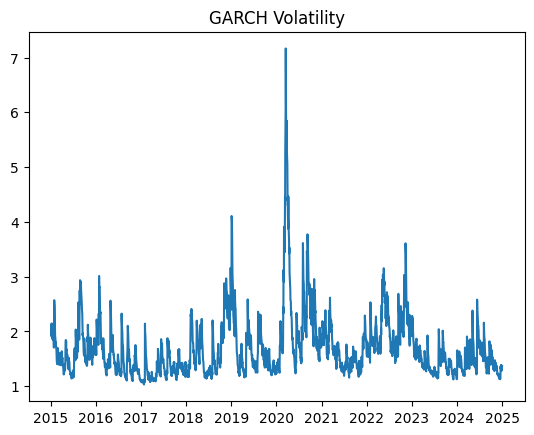

In [18]:
data['Volatility'] = result.conditional_volatility
plt.plot(data['Volatility'])
plt.title("GARCH Volatility")
plt.show()